### Machine learning for predicting the magnetic flux rope structure in coronal mass ejections (Bz)

Coronal mass ejections continually interact with Earth's space weather environment driving geomagnetic storm activity. The severity of geomagnetic storms is determined by the magnetic flux rope structure in the coronal mass ejections. Predicting the flux rope structure is however an open question in the community. Here we study if the in situ signature in the sheath region contains sufficient information for predicting the magnetic flux rope field in coronal mass ejections. Further, we quantify how much time is needed inside the flux rope to predict the mean total magnetic field of the flux rope with high accuracy. To do so, we use widely-applied machine learning algorithms such as linear regression, lars lasso, and random forest. We train, test, and validate these algorithms on coronal mass ejections in retrospective real-time mode for the Wind, Stereo-A, and Stereo-B mission data in the HELCATS CME catalog. 

#### Contributors: 
M.A. Reiss, C. Möstl, R.L. Bailey, and U. Amerstorfer (Space Research Institute IWF, Graz, Austria)

#### Solar wind data:
Copy Version 8 from https://figshare.com/articles/dataset/Solar_wind_in_situ_data_suitable_for_machine_learning_python_numpy_arrays_STEREO-A_B_Wind_Parker_Solar_Probe_Ulysses_Venus_Express_MESSENGER/12058065
into the folder /data.

In [1]:
# Python Modules and Packages
import os
import sys
import copy
import matplotlib.pyplot as plt
from matplotlib.dates import date2num, num2date
from matplotlib import cm
import numpy as np
import pickle
from scipy import stats
import scipy.io
import time

# Visualisation
#import sunpy.time
import seaborn as sns
import pandas as pd
from pandas.plotting import scatter_matrix
#from sunpy.time import parse_time

# Machine learning
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_classif
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.linear_model import ElasticNet, HuberRegressor, Lars, LassoLars
from sklearn.linear_model import PassiveAggressiveRegressor, RANSACRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Don't print warnings
import warnings
warnings.filterwarnings('ignore')

# Print versions
print('Current Versions')
import matplotlib
print(np.__version__)#==1.17.2
print(matplotlib.__version__)#3.1.2
print(scipy.__version__)#1.3.1
print(pd.__version__)#0.25.3
import sklearn
print(sklearn.__version__)#0.20.3
print(sns.__version__)#0.9.0
import PIL
print(PIL.__version__)#8.1.2

os.system('jupyter nbconvert --to script mfrpred_mreiss_bz.ipynb')    

Current Versions
2.3.1
3.10.3
1.15.3
2.3.0
1.7.0
0.13.2
11.2.1


1

## 1. Data preparation

#### File and folder variables:

In [2]:
# Make plots and results folders
mfrdir = 'mfr_predict'
if os.path.isdir(mfrdir) == False: 
    os.mkdir(mfrdir)

plotdir = 'plots'
if os.path.isdir(plotdir) == False: 
    os.mkdir(plotdir)
    
# File names to save features into
savepath_win = 'wind_features.p'
savepath_sta = 'sta_features.p'
savepath_stb = 'stb_features.p'

#### Load HELCATS ICME data catalog

In [3]:
[ic,header,parameters] = pickle.load(open('data/HELCATS_ICMECAT_v20_pandas.p', "rb" ))

# Spacecraft
isc = ic.loc[:,'sc_insitu'] 

# Shock arrival or density enhancement time
icme_start_time = ic.loc[:,'icme_start_time']
icme_start_time_num = date2num(np.array(icme_start_time))

# Start time of the magnetic obstacle (mo)
mo_start_time = ic.loc[:,'mo_start_time']
mo_start_time_num = date2num(np.array(mo_start_time))

# End time of the magnetic obstacle (mo)
mo_end_time = ic.loc[:,'mo_end_time']
mo_end_time_num = date2num(np.array(mo_end_time))

#get indices for each target
wini=np.where(ic.sc_insitu=='Wind')[0]
stai=np.where(ic.sc_insitu=='STEREO-A')[0]
stbi=np.where(ic.sc_insitu=='STEREO-B')[0]
pspi=np.where(ic.sc_insitu=='PSP')[0]
soloi=np.where(ic.sc_insitu=='SolarOrbiter')[0]
bepii=np.where(ic.sc_insitu=='BepiColombo')[0]
ulyi=np.where(ic.sc_insitu=='Ulysses')[0]
messi=np.where(ic.sc_insitu=='Messenger')[0]
vexi=np.where(ic.sc_insitu=='VEX')[0]

#### Load spacecraft data

In [4]:
# Load Wind data
[win, winheader] = pickle.load(open("data/wind_2007_2021_heeq_ndarray.p", "rb"))

# Load STEREO-A data
[sta, atta] = pickle.load(open("data/stereoa_2007_2021_sceq_ndarray.p", "rb"))

# Load STEREO-B data
[stb, attb, stbheader] = pickle.load(open("data/stereob_2007_2014_sceq_ndarray.p", "rb"))

#### Convert spacecraft data to dataframe

In [5]:
# Wind
win_orig = copy.deepcopy(win)
variable_list_all = ['time', 'bx', 'by', 'bz', 'bt', 'vt', 'np', 'tp']
dt = [(v, win[v].dtype) for v in variable_list_all]
dt += [('bt2', win['bt'].dtype), ('vtbz', win['bt'].dtype)]
win_data = np.zeros(len(win), dtype=dt)

for v in variable_list_all:
    win_data[v] = win[v]
win_data['bt2'] = win['bt']*win['bt']
win_data['vtbz'] = win['vt']*win['bz']
win = win_data

# STEREO-A
sta_orig = copy.deepcopy(sta)
dt = [(v, sta[v].dtype) for v in variable_list_all]
dt += [('bt2', sta['bt'].dtype), ('vtbz', sta['bt'].dtype)]
sta_data = np.zeros(len(sta), dtype=dt)

for v in variable_list_all:
    sta_data[v] = sta[v]
sta_data['bt2']  = sta['bt']*sta['bt']
sta_data['vtbz'] = sta['vt']*sta['bz']
sta = sta_data

# STEREO-B
stb_orig = copy.deepcopy(stb)
dt = [(v, stb[v].dtype) for v in variable_list_all]
dt += [('bt2', stb['bt'].dtype), ('vtbz', stb['bt'].dtype)]
stb_data = np.zeros(len(stb), dtype=dt)

for v in variable_list_all:
    stb_data[v] = stb[v]
stb_data['bt2']  = stb['bt']*stb['bt']
stb_data['vtbz'] = stb['vt']*stb['bz']
stb = stb_data

#### Study only events with a sheath region

In [6]:
# Event indices from STEREO and Wind
istaind = np.where(isc == 'STEREO-A')[0]
istbind = np.where(isc == 'STEREO-B')[0]
iwinind = np.where(isc == 'Wind')[0]

# Event indices where the start time of the CME does not match the start time of the magnetic obstacle
n_iwinind = np.where(icme_start_time_num[iwinind] != mo_start_time_num[iwinind])[0]
n_istaind = np.where(icme_start_time_num[istaind] != mo_start_time_num[istaind])[0]
n_istbind = np.where(icme_start_time_num[istbind] != mo_start_time_num[istbind])[0]

# Correct indicies to take from all data, not just subset
i_icme_start_time_num = np.arange(len(icme_start_time_num))
n_iwinind = i_icme_start_time_num[iwinind][n_iwinind]
n_istaind = i_icme_start_time_num[istaind][n_istaind]
n_istbind = i_icme_start_time_num[istbind][n_istbind]

# Count the number of selected events
print("Events with a sheath region in WIND    : {} / {}".format(n_iwinind.shape[0], iwinind.shape[0]))   # TODO
print("Events with a sheath region in STEREO-A: {} / {}".format(n_istaind.shape[0], istaind.shape[0]))
print("Events with a sheath region in STEREO-B: {} / {}".format(n_istbind.shape[0], istbind.shape[0]))
print("Number of Events with a sheath region  :", n_iwinind.shape[0] + n_istaind.shape[0] + n_istbind.shape[0])
print('Number of all events',np.round(np.size(stbi)+np.size(wini)+np.size(stai)))
print('Percentage of all events',np.round((n_iwinind.shape[0] + n_istaind.shape[0] + n_istbind.shape[0])/ (np.size(stbi)+np.size(wini)+np.size(stai))*100))

# Indices of all selected events
#n_all1=np.hstack([n_iwinind,n_istaind,n_istbind])

Events with a sheath region in WIND    : 149 / 186
Events with a sheath region in STEREO-A: 135 / 222
Events with a sheath region in STEREO-B: 78 / 150
Number of Events with a sheath region  : 362
Number of all events 558
Percentage of all events 65.0


#### Timing windows for features and labels

In [7]:
# Set time window for features in hours
feature_hours = 4 #10

# Decide if you want to include the sheath region. 
use_sheath = True

if use_sheath:
    print("Option 1: Use MFR and sheath data for features")
    event_start = icme_start_time_num
else:
    print("Option 2: Use MFR and no sheath data for features")
    event_start = mo_start_time_num

# Define end of the event time window
event_end = mo_start_time_num + feature_hours / 24.0
      
# Define timing window of labels
label_start = mo_start_time_num
label_end = mo_end_time_num

Option 1: Use MFR and sheath data for features


#### Functions to compute features and labels

In [8]:
# Compute mean, max and std-dev in feature time window
def get_feature(name, sc_time, start_time, end_time, sc_ind, sc_feature):
    feature_mean = np.zeros(np.size(sc_ind))
    feature_max = np.zeros(np.size(sc_ind))
    feature_std = np.zeros(np.size(sc_ind))
    feature_min = np.zeros(np.size(sc_ind))
    feature_cv  = np.zeros(np.size(sc_ind))
    feature_minmax = np.zeros(np.size(sc_ind))
    
    for p in np.arange(0, np.size(sc_ind)):
        time_slice = np.where(np.logical_and(sc_time > start_time[sc_ind[p]], sc_time < end_time[sc_ind[p]]))
        feature_slice = sc_feature[time_slice]
        feature_mean[p] = np.nanmean(feature_slice)
        feature_std[p] = np.nanstd(feature_slice)
        
        # Compute coefficient of variation (CV)
        feature_cv[p] = feature_std[p]/np.abs(feature_mean[p])
        
        feature_temp = feature_slice[np.isfinite(feature_slice)]
        
        #save indices of selected events
        if name=='win': win_select_ind.append(sc_ind[p])              
        if name=='sta': sta_select_ind.append(sc_ind[p])
        if name=='stb': stb_select_ind.append(sc_ind[p])
        
        try:
            feature_max[p] = np.max(feature_temp)
            feature_min[p] = np.min(feature_temp)
            feature_minmax[p] = feature_min[p]/feature_max[p]
        except ValueError:  # raised if `y` is empty.
            pass

    return feature_mean, feature_max, feature_std, feature_min, feature_cv, feature_minmax

# Compute either 'max' or 'mean' of total magnetic field in label time window
def get_label(sc_time, start_time, end_time, sc_ind, sc_label, label_type="max"):
    label_mean = np.zeros(np.size(sc_ind))
    label_max = np.zeros(np.size(sc_ind))
    label_min = np.zeros(np.size(sc_ind))

    for p in np.arange(0, np.size(sc_ind)):
        time_slice = np.where(np.logical_and(sc_time > start_time[sc_ind[p]], sc_time < end_time[sc_ind[p]]))
        label_slice = sc_label[time_slice]
        if len(label_slice) == 0:
            label_max[p] = np.nan
            label_min[p] = np.nan
            label_mean[p] = np.nan
        else:
            label_max[p] = np.nanmax(label_slice)
            label_min[p] = np.min([np.nanmin(label_slice), 0])
            label_mean[p] = np.nanmean(label_slice)
            
    if label_type == 'max':
        return label_max
    elif label_type == 'min':
        return label_min
    elif label_type == 'mean':
        return label_mean

#### Create data frame for features and labels

In [9]:
#contains all events that are finally selected
win_select_ind=[]
sta_select_ind=[]
stb_select_ind=[]

# Define target in label time window
target_type = 'min'

# List of physical properties
variable_list = ['bx', 'by', 'bz', 'bt', 'vt','np','tp']

# If file doesn't exist, create it, otherwise load it
if not os.path.exists("mfr_predict/bz_fh{:.0f}_sta_features.p".format(feature_hours)):
    start_time = time.time()
    print("Option 1: Compute features...")

    # Wind features
    dwin = {}
    for variable in variable_list:
        all_var_features = get_feature('win',win['time'], event_start, event_end, n_iwinind, win[variable])
        dwin['mean('+variable+')'] = all_var_features[0]
        dwin['max('+variable+')'] = all_var_features[1]
        dwin['std('+variable+')'] = all_var_features[2]
        dwin['min('+variable+')'] = all_var_features[3]
        dwin['cv('+variable+')'] = all_var_features[4]
        dwin['minmax('+variable+')'] = all_var_features[5]

    # Wind labels
    label_btotmean = get_label(win['time'], label_start, label_end, n_iwinind, win['bz'], label_type=target_type)
    dwin['Target'] = label_btotmean
    
    # Create dataframe
    dfwin = pd.DataFrame(data=dwin)
    pickle.dump(dfwin, open(os.path.join(mfrdir, 'bz_fh{:.0f}_'.format(feature_hours) + savepath_win), "wb"))
    
    #dump original indices
    win_select_size=int(len(win_select_ind)/len(variable_list))
    win_select_ind=win_select_ind[0:win_select_size]
    pickle.dump(win_select_ind, open(os.path.join(mfrdir, 'bz_orig_ind_' + savepath_win), "wb"))
    
    ################### STEREO-A features
    dsta = {}
    for variable in variable_list:
        all_var_features = get_feature('sta',sta['time'], event_start, event_end, 
                                       n_istaind, sta[variable])
        dsta['mean('+variable+')'] = all_var_features[0]
        dsta['max('+variable+')'] = all_var_features[1]
        dsta['std('+variable+')'] = all_var_features[2]
        dsta['min('+variable+')'] = all_var_features[3]
        dsta['cv('+variable+')'] = all_var_features[4]
        dsta['minmax('+variable+')'] = all_var_features[5]

    # STEREO-A labels
    label_btotmean = get_label(sta['time'], label_start, label_end, n_istaind, sta['bz'], label_type=target_type)
    dsta['Target'] = label_btotmean
    
    # Create dateframe
    dfsta = pd.DataFrame(data=dsta)
    pickle.dump(dfsta, open(os.path.join(mfrdir, 'bz_fh{:.0f}_'.format(feature_hours) + savepath_sta), "wb"))
    
    #dump original indices
    sta_select_size=int(len(sta_select_ind)/len(variable_list))
    sta_select_ind=sta_select_ind[0:sta_select_size]
    pickle.dump(sta_select_ind, open(os.path.join(mfrdir, 'bz_orig_ind_' + savepath_sta), "wb"))

    #################### STEREO-B features
    dstb = {}
    for variable in variable_list:
        all_var_features = get_feature('stb',stb['time'], event_start, event_end, 
                                       n_istbind, stb[variable])
        dstb['mean('+variable+')'] = all_var_features[0]
        dstb['max('+variable+')'] = all_var_features[1]
        dstb['std('+variable+')'] = all_var_features[2]
        dstb['min('+variable+')'] = all_var_features[3]
        dstb['cv('+variable+')'] = all_var_features[4]
        dstb['minmax('+variable+')'] = all_var_features[5]

    # STEREO-B labels
    label_btotmean = get_label(stb['time'], label_start, label_end, n_istbind, stb['bz'], label_type=target_type)
    dstb['Target'] = label_btotmean
    
    # Create dataframe
    dfstb = pd.DataFrame(data=dstb)
    pickle.dump(dfstb, open(os.path.join(mfrdir, 'bz_fh{:.0f}_'.format(feature_hours) + savepath_stb), "wb"))

    #dump original indices
    stb_select_size=int(len(stb_select_ind)/len(variable_list))
    stb_select_ind=stb_select_ind[0:stb_select_size]
    pickle.dump(stb_select_ind, open(os.path.join(mfrdir, 'bz_orig_ind_' + savepath_stb), "wb"))

    print("Option 1: Computation of data frame for Wind, STEREO-A, and STEREO-B completed")   
    end_time = time.time()
    print("Computation of features took {:.1f} minutes.".format((end_time - start_time)/60.))
else:
    print("Option 2: Loading existing data frames...")
    dfwin = pickle.load(open(os.path.join(mfrdir, 'bz_fh{:.0f}_'.format(feature_hours) + savepath_win), "rb"))
    dfsta = pickle.load(open(os.path.join(mfrdir, 'bz_fh{:.0f}_'.format(feature_hours) + savepath_sta), "rb"))
    dfstb = pickle.load(open(os.path.join(mfrdir, 'bz_fh{:.0f}_'.format(feature_hours) + savepath_stb), "rb"))
    print("Option 2: Loading existing data frame completed")

Option 2: Loading existing data frames...
Option 2: Loading existing data frame completed


#### Clean the data frame by removing NaNs 

In [10]:
#get original indices of the 362 events
win_select_ind = pickle.load(open(os.path.join(mfrdir, 'bz_orig_ind_' + savepath_win), "rb"))
sta_select_ind= pickle.load(open(os.path.join(mfrdir, 'bz_orig_ind_' + savepath_sta), "rb"))
stb_select_ind = pickle.load(open(os.path.join(mfrdir, 'bz_orig_ind_' + savepath_stb), "rb"))

win_select_ind=np.array(win_select_ind)
sta_select_ind=np.array(sta_select_ind)
stb_select_ind=np.array(stb_select_ind)

print(len(dfwin)+len(dfsta)+len(dfstb))
print(len(win_select_ind)+len(sta_select_ind)+len(stb_select_ind))

362
362


In [11]:
print(len(dfwin))
print(len(dfsta))
print(len(dfstb))

# Events before tidying up
len_dfwin_nans = len(dfwin)
len_dfsta_nans = len(dfsta)
len_dfstb_nans = len(dfstb)

print("Total number of events  ", len(dfwin)+len(dfsta)+len(dfstb))
print()

# Remove NaN's in data frames
dfwin1 = dfwin.dropna()
dfsta1 = dfsta.dropna()
dfstb1 = dfstb.dropna()

# Get indices of nans
win_nan=np.array(dfwin[dfwin.isna().any(axis=1)].index)
sta_nan=np.array(dfsta[dfsta.isna().any(axis=1)].index)
stb_nan=np.array(dfstb[dfstb.isna().any(axis=1)].index)

win_select_ind1=np.delete(win_select_ind,win_nan)
sta_select_ind1=np.delete(sta_select_ind,sta_nan)
stb_select_ind1=np.delete(stb_select_ind,stb_nan)

#print(len(dfwin1), len(win_select_ind1))
#print(len(dfsta1),len(sta_select_ind1))
#print(len(dfstb1),len(stb_select_ind1))

print("{} nans removed from WIND data".format(len_dfwin_nans-len(dfwin1)))
print("{} nans removed from STEREO-A data".format(len_dfsta_nans-len(dfsta1)))
print("{} nans removed from STEREO-B data".format(len_dfstb_nans-len(dfstb1)))
print("Total number of events left:  ", len(dfwin1)+len(dfsta1)+len(dfstb1))

#n_all are now the indices of all 348 selected events in the ICMECAT
n_all=np.hstack([win_select_ind1,sta_select_ind1,stb_select_ind1])
print(len(n_all))

149
135
78
Total number of events   362

0 nans removed from WIND data
12 nans removed from STEREO-A data
2 nans removed from STEREO-B data
Total number of events left:   348
348


In [12]:
# Define final dataframes
dfwin=dfwin1
dfsta=dfsta1
dfstb=dfstb1

## Figure 1: ICME catalog 

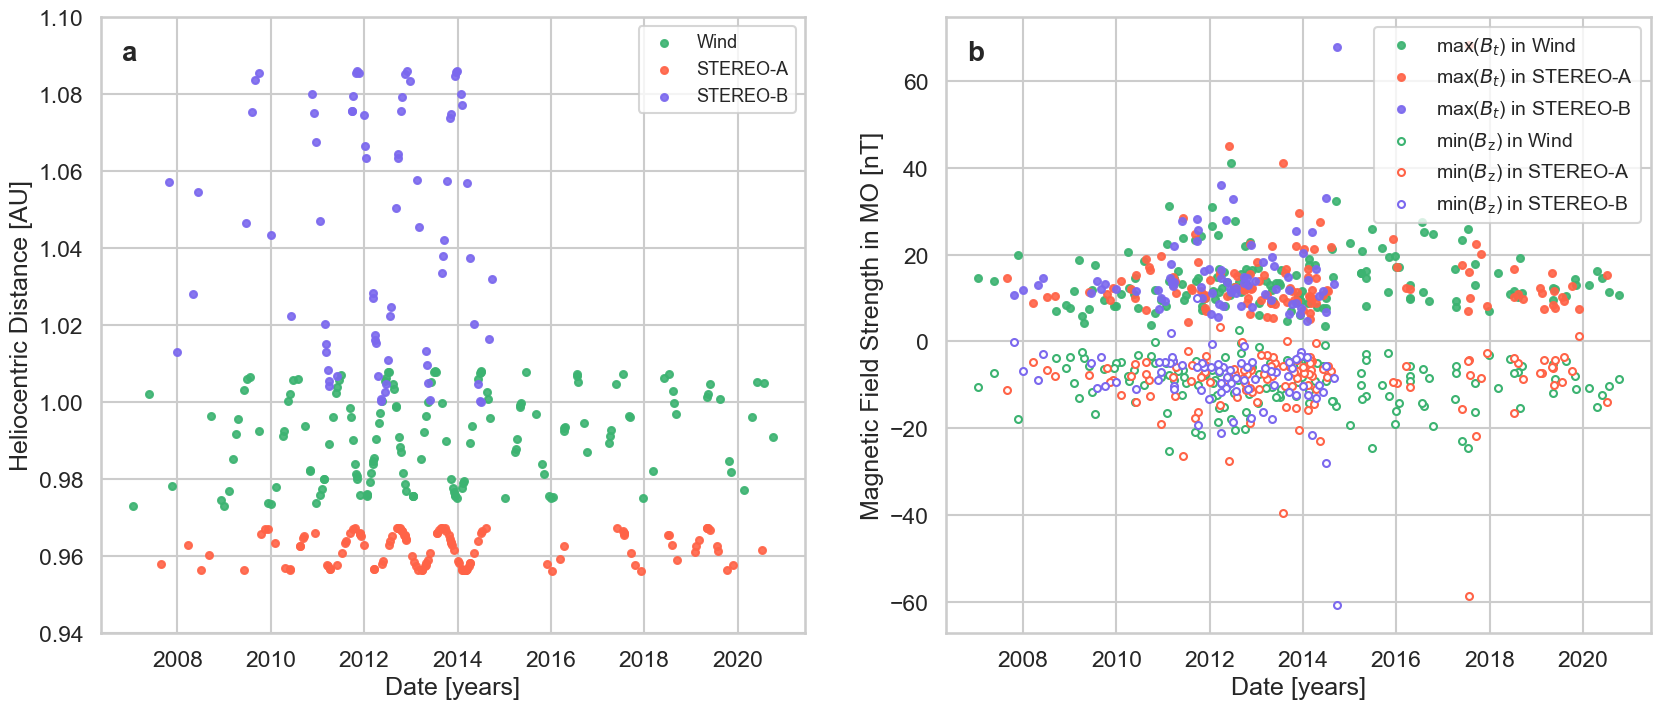

Selected events with sheath:
Number of events: Wind,  149
Number of events: STA,  123
Number of events: STB,  76
Total: 348


In [13]:
#markersize
ms=25
#alpha
al=0.9

sns.set_context("talk")     
sns.set_style('whitegrid')

fig=plt.figure(figsize=(20,8),dpi=100)
ax1 = plt.subplot(121) 
ax1.scatter(ic.loc[win_select_ind1,'icme_start_time'], ic.loc[win_select_ind1,'mo_sc_heliodistance'], label='Wind', s=ms,c='mediumseagreen', alpha=al)
ax1.scatter(ic.loc[sta_select_ind1,'icme_start_time'], ic.loc[sta_select_ind1,'mo_sc_heliodistance'], label='STEREO-A',s=ms,c='tomato', alpha=al)
ax1.scatter(ic.loc[stb_select_ind1,'icme_start_time'], ic.loc[stb_select_ind1,'mo_sc_heliodistance'], label='STEREO-B',s=ms,c='mediumslateblue', alpha=al)
plt.ylabel('Heliocentric Distance [AU]')
plt.xlabel('Date [years]')
plt.ylim([0.94,1.1])
plt.legend(loc=1,fontsize=13)

ax2 = plt.subplot(122) 
#ax2.scatter(ic.loc[wini,'mo_sc_heliodistance'],ic.loc[wini,'mo_bmean'], label='Wind', s=ms,c='mediumseagreen', alpha=al)
#ax2.scatter(ic.loc[stai,'mo_sc_heliodistance'],ic.loc[stai,'mo_bmean'], label='STEREO-A',s=ms,c='red', alpha=al)
#ax2.scatter(ic.loc[stbi,'mo_sc_heliodistance'],ic.loc[stbi,'mo_bmean'], label='STEREO-B',s=ms,c='blue', alpha=al)
ax2.scatter(ic.loc[win_select_ind1,'icme_start_time'],ic.loc[win_select_ind1,'mo_bmax'], label='max($B_t$) in Wind', s=ms,c='mediumseagreen', alpha=al)
ax2.scatter(ic.loc[sta_select_ind1,'icme_start_time'],ic.loc[sta_select_ind1,'mo_bmax'], label='max($B_t$) in STEREO-A',s=ms,c='tomato', alpha=al)
ax2.scatter(ic.loc[stb_select_ind1,'icme_start_time'],ic.loc[stb_select_ind1,'mo_bmax'], label='max($B_t$) in STEREO-B',s=ms,c='mediumslateblue', alpha=al)
ax2 = plt.subplot(122) 

al=1.0
ax2.scatter(ic.loc[win_select_ind1,'icme_start_time'],ic.loc[win_select_ind1,'mo_bzmin'], linestyle='None',marker='o',s=ms,edgecolors='mediumseagreen',facecolors='white',label='min($B_{\mathrm{z}}$) in Wind', alpha=al)
ax2.scatter(ic.loc[sta_select_ind1,'icme_start_time'],ic.loc[sta_select_ind1,'mo_bzmin'], linestyle='None',marker='o',s=ms,label='min($B_{\mathrm{z}}$) in STEREO-A',facecolors='white',edgecolors='tomato', alpha=al)
ax2.scatter(ic.loc[stb_select_ind1,'icme_start_time'],ic.loc[stb_select_ind1,'mo_bzmin'], linestyle='None',marker='o',s=ms,label='min($B_{\mathrm{z}}$) in STEREO-B',facecolors='white',edgecolors='mediumslateblue', alpha=al)
plt.xlabel('Date [years]')
ax2.set_ylabel('Magnetic Field Strength in MO [nT]')
ax2.legend(loc=1,fontsize=14)

# Add labels to plots
for ax, ann in zip([ax1, ax2], ['a', 'b']):
    ax.text(0.03, .93, ann, transform=ax.transAxes, fontsize=20, weight='bold')

#for ax, ann in zip([ax1, ax2], ['a', 'b']):
#    ax.text(0.02, .93, ann, transform=ax.transAxes, fontsize=32, weight='bold')
argv3 ='fig1_icmecat.pdf'
plt.savefig('plots/' + argv3, bbox_inches='tight')
argv3 ='fig1_icmecat.png'
plt.savefig('plots/' + argv3, bbox_inches='tight')
plt.show()

print('Selected events with sheath:')
print('Number of events: Wind, ',np.size(win_select_ind1))
print('Number of events: STA, ',np.size(sta_select_ind1))
print('Number of events: STB, ',np.size(stb_select_ind1))
print('Total:',np.size(win_select_ind1)+np.size(sta_select_ind1)+np.size(stb_select_ind1))

## Figure 2: Parameter distribution plot 

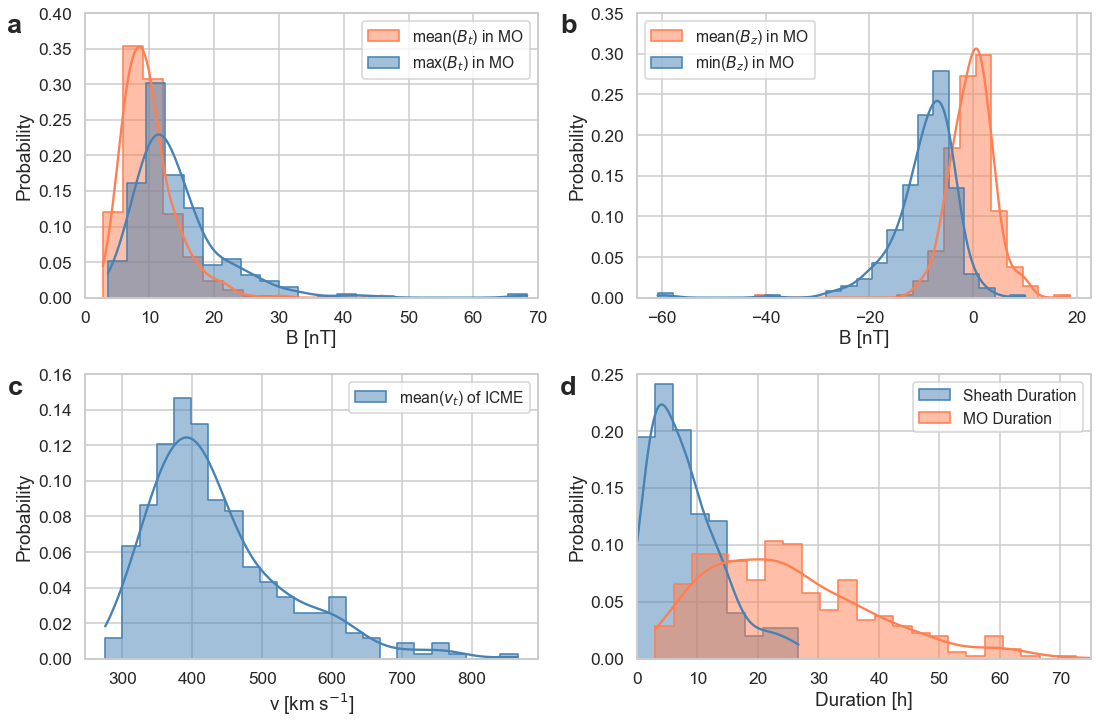

In [14]:
sns.set_context("talk")     
sns.set_style('whitegrid')

fig=plt.figure(figsize=(15,10),dpi=75)

fs=15
ax1 = plt.subplot(221) 
sns.histplot(ic.loc[n_all,'mo_bmean'], label='mean($B_t$) in MO',color='coral',alpha=0.5,kde=True,stat='probability',element='step', binwidth = 3)
sns.histplot(ic.loc[n_all,'mo_bmax'], label='max($B_t$) in MO',color='steelblue',kde=True,stat='probability', element='step', binwidth = 3)
ax1.set_xlabel('B [nT]')
ax1.set_ylim(0,0.4)
ax1.set_xlim(0,70)
plt.legend(loc=1,fontsize=fs)

ax2 = plt.subplot(222) 
sns.histplot(ic.loc[n_all,'mo_bzmean'],label='mean($B_z$) in MO',color='coral',alpha=0.5,kde=True,stat='probability', element='step', binwidth = 3)
sns.histplot(ic.loc[n_all,'mo_bzmin'],label='min($B_z$) in MO',color='steelblue',kde=True,stat='probability', element='step', binwidth = 3)
ax2.set_xlabel('B [nT]')
#ax2.set_ylabel('')
ax2.set_ylim(0,0.35)
plt.legend(loc=2,fontsize=fs)

ax3 = plt.subplot(223) 
sns.histplot(ic.loc[n_all,'icme_speed_mean'],label='mean($v_t$) of ICME',color='steelblue',kde=True,stat='probability', element='step', binwidth = 25)
ax3.set_xlabel('v [km s$^{-1}$]')
ax3.set_ylim(0,0.16)
plt.legend(loc=1,fontsize=fs)

ax4 = plt.subplot(224) 
sns.histplot(ic.loc[n_all,'icme_duration']-ic.loc[n_iwinind,'mo_duration'],label='Sheath Duration',color='steelblue',kde=True,stat='probability', element='step',binwidth = 3)
sns.histplot(ic.loc[n_all,'mo_duration'],label='MO Duration',color='coral',kde=True,stat='probability', element='step',binwidth = 3)
ax4.set_xlabel('Duration [h]')

ax4.set_xlim(0,75)
#ax4.set_ylabel('')
plt.legend(loc=1,fontsize=fs)
ax4.set_ylim(0,0.25)

#ax4 = plt.subplot(234) 
#sns.histplot(ic.loc[n_iwinind,'mo_density_mean'],label='MO <$N_p$>',color='steelblue',kde=True,stat='probability', element='step')
#ax4.set_xlabel('N [ccm$^{-3}$]')#
#ax4.set_ylim(0,0.25)
#ax4.set_ylabel('')
#plt.legend(loc=1)

#ax5 = plt.subplot(235) 
#sns.histplot(ic.loc[n_iwinind,'mo_temperature_mean'],label='MO <$T_p$>',color='steelblue',kde=True,stat='probability', element='step')
#ax5.set_xlabel('hours')
#ax5.set_ylim(0,0.25)#
#ax5.set_ylabel('')
#plt.legend(loc=1)
#plt.tight_layout()

plt.tight_layout()

# Add labels to plots
for ax, ann in zip([ax1, ax2, ax3, ax4], ['a', 'b','c','d']):
    ax.text(-0.17, .93, ann, transform=ax.transAxes, fontsize=26, weight='bold')

argv3 ='fig2_dist.pdf'
plt.savefig('plots/' + argv3)
argv3 ='fig2_dist.png'
plt.savefig('plots/' + argv3)

In [15]:
print('Statistics for the final '+str(len(n_all))+' selected events with sheath:')
print()
print("Average ICME length   : {:.2f} hours".format(((mo_end_time_num[n_all] - icme_start_time_num[n_all])*24.).mean()))
print("Average MO length     : {:.2f} hours".format(((mo_end_time_num[n_all] - mo_start_time_num[n_all])*24.).mean()))
print("Average SHEATH length : {:.2f} hours".format(((mo_start_time_num[n_all] - icme_start_time_num[n_all])*24.).mean()))
print()
print("STD ICME length       : {:.2f} hours".format(((mo_end_time_num[n_all] - icme_start_time_num[n_all])*24.).std()))
print("STD MO length         : {:.2f} hours".format(((mo_end_time_num[n_all] - mo_start_time_num[n_all])*24.).std()))
print("STD SHEATH length     : {:.2f} hours".format(((mo_start_time_num[n_all] - icme_start_time_num[n_all])*24.).std()))

print()
print("Average MO Bt max   : {:.2f} nT".format((ic.loc[n_all,'mo_bmax'].mean())))
print("std MO Bt max   : {:.2f} nT".format((ic.loc[n_all,'mo_bmax'].std())))
print()

print("Average MO Bt   : {:.2f} nT".format((ic.loc[n_all,'mo_bmean'].mean())))
print("std MO Bt   : {:.2f} nT".format((ic.loc[n_all,'mo_bmean'].std())))
print()
print("Average MO Bz   : {:.2f} nT".format((ic.loc[n_all,'mo_bzmean'].mean())))
print("std MO Bz   : {:.2f} nT".format((ic.loc[n_all,'mo_bzmean'].std())))
print()
print("Average MO Bzmin   : {:.2f} nT".format((ic.loc[n_all,'mo_bzmin'].mean())))
print("std MO Bzmin   : {:.2f} nT".format((ic.loc[n_all,'mo_bzmin'].std())))

#print("Average SHEATH length : {:.2f} hours".format(((mo_start_time_num[n_all] - icme_start_time_num[n_all])*24.).mean()))
print()

Statistics for the final 348 selected events with sheath:

Average ICME length   : 34.26 hours
Average MO length     : 25.24 hours
Average SHEATH length : 9.02 hours

STD ICME length       : 17.02 hours
STD MO length         : 14.60 hours
STD SHEATH length     : 6.02 hours

Average MO Bt max   : 14.32 nT
std MO Bt max   : 7.57 nT

Average MO Bt   : 9.95 nT
std MO Bt   : 4.47 nT

Average MO Bz   : -0.32 nT
std MO Bz   : 4.65 nT

Average MO Bzmin   : -9.43 nT
std MO Bzmin   : 6.79 nT



In [16]:
"""#Some tests...
event_num = 5
time_event = stb['time'][np.logical_and(stb['time'] > icme_start_time_num[n_istbind][event_num], stb['time'] < mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0)]
prop_event = stb['bt'][np.logical_and(stb['time'] > icme_start_time_num[n_istbind][event_num], stb['time'] < mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0)]
time_label = stb['time'][np.logical_and(stb['time'] > mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0, stb['time'] < mo_end_time_num[n_istbind][event_num])]
prop_label = stb['bt'][np.logical_and(stb['time'] > mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0, stb['time'] < mo_end_time_num[n_istbind][event_num])]
plt.plot(time_event,prop_event)
plt.plot(time_label,prop_label)
plt.scatter(icme_start_time_num[n_istbind][event_num],0.6, color='y')
plt.axvline(icme_start_time_num[n_istbind][event_num], color='y')
plt.scatter(mo_start_time_num[n_istbind][event_num],0.5, color='g')
plt.scatter(mo_start_time_num[n_istbind][event_num] + feature_hours / 24.0,0.4, color='b')
plt.scatter(mo_end_time_num[n_istbind][event_num],0.3, color='r')

print(np.nanmean(prop_event))
print(np.nanmax(prop_event))
print(np.nanstd(prop_event))
print(np.nanmin(prop_event))
print(np.nanstd(prop_event)/np.nanmean(prop_event))
print(np.nanmin(prop_event)/np.nanmax(prop_event))
#print(np.nanmean(prop_label))stb
"""

"#Some tests...\nevent_num = 5\ntime_event = stb['time'][np.logical_and(stb['time'] > icme_start_time_num[n_istbind][event_num], stb['time'] < mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0)]\nprop_event = stb['bt'][np.logical_and(stb['time'] > icme_start_time_num[n_istbind][event_num], stb['time'] < mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0)]\ntime_label = stb['time'][np.logical_and(stb['time'] > mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0, stb['time'] < mo_end_time_num[n_istbind][event_num])]\nprop_label = stb['bt'][np.logical_and(stb['time'] > mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0, stb['time'] < mo_end_time_num[n_istbind][event_num])]\nplt.plot(time_event,prop_event)\nplt.plot(time_label,prop_label)\nplt.scatter(icme_start_time_num[n_istbind][event_num],0.6, color='y')\nplt.axvline(icme_start_time_num[n_istbind][event_num], color='y')\nplt.scatter(mo_start_time_num[n_istbind][event_num],0.5, color='g')\nplt

In [17]:
"""#Some tests...
event_num = 5
time_event = stb['time'][np.logical_and(stb['time'] > icme_start_time_num[n_istbind][event_num], stb['time'] < mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0)]
prop_event = stb['bt'][np.logical_and(stb['time'] > icme_start_time_num[n_istbind][event_num], stb['time'] < mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0)]
time_label = stb['time'][np.logical_and(stb['time'] > mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0, stb['time'] < mo_end_time_num[n_istbind][event_num])]
prop_label = stb['bt'][np.logical_and(stb['time'] > mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0, stb['time'] < mo_end_time_num[n_istbind][event_num])]
plt.plot(time_event,prop_event)
plt.plot(time_label,prop_label)
plt.scatter(icme_start_time_num[n_istbind][event_num],0.6, color='y')
plt.axvline(icme_start_time_num[n_istbind][event_num], color='y')
plt.scatter(mo_start_time_num[n_istbind][event_num],0.5, color='g')
plt.scatter(mo_start_time_num[n_istbind][event_num] + feature_hours / 24.0,0.4, color='b')
plt.scatter(mo_end_time_num[n_istbind][event_num],0.3, color='r')

print(np.nanmean(prop_event))
print(np.nanmax(prop_event))
print(np.nanstd(prop_event))
print(np.nanmin(prop_event))
print(np.nanstd(prop_event)/np.nanmean(prop_event))
print(np.nanmin(prop_event)/np.nanmax(prop_event))
#print(np.nanmean(prop_label))stb
"""

"#Some tests...\nevent_num = 5\ntime_event = stb['time'][np.logical_and(stb['time'] > icme_start_time_num[n_istbind][event_num], stb['time'] < mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0)]\nprop_event = stb['bt'][np.logical_and(stb['time'] > icme_start_time_num[n_istbind][event_num], stb['time'] < mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0)]\ntime_label = stb['time'][np.logical_and(stb['time'] > mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0, stb['time'] < mo_end_time_num[n_istbind][event_num])]\nprop_label = stb['bt'][np.logical_and(stb['time'] > mo_start_time_num[n_istbind][event_num]+ feature_hours / 24.0, stb['time'] < mo_end_time_num[n_istbind][event_num])]\nplt.plot(time_event,prop_event)\nplt.plot(time_label,prop_label)\nplt.scatter(icme_start_time_num[n_istbind][event_num],0.6, color='y')\nplt.axvline(icme_start_time_num[n_istbind][event_num], color='y')\nplt.scatter(mo_start_time_num[n_istbind][event_num],0.5, color='g')\nplt

## 2. Machine Learning

#### Split data frame into training and testing

In [18]:
# Testing data size in percent
test_size = 0.3

# Split into training and testing data
win_train, win_test = train_test_split(dfwin, test_size=test_size, random_state=42)
sta_train, sta_test = train_test_split(dfsta, test_size=test_size, random_state=42)
stb_train, stb_test = train_test_split(dfstb, test_size=test_size, random_state=42)

# Combine spacecraft datasets
train = pd.concat([win_train, sta_train, stb_train])
test = pd.concat([win_test, sta_test, stb_test])

# Save the index of the events, as appearing in the data frames, to a numpy array
win_train_ind = win_train.index.to_numpy()
win_test_ind  = win_test.index.to_numpy()
sta_train_ind = sta_train.index.to_numpy()
sta_test_ind  = sta_test.index.to_numpy()
stb_train_ind = stb_train.index.to_numpy()
stb_test_ind  = stb_test.index.to_numpy()

# Calculate indices for training and testing data frame
train_ind = train.index.to_numpy()
test_ind = test.index.to_numpy()

#### Feature selection

In [19]:
# Select features
use_features = list(train.columns)
use_features.remove('Target')

# Bring data into shape for machine learning models
if len(use_features) == 1:
    X_train = np.array(train[use_features]).reshape(-1, 1)
    X_test = np.array(test[use_features]).reshape(-1, 1)
else:
    X_train = np.array(train[use_features])
    X_test = np.array(test[use_features])
    
y_train = np.array(train['Target']).reshape(-1, 1)
y_test = np.array(test['Target']).reshape(-1, 1)

# Use pickle to save training and testing data
fname = os.path.join(mfrdir, 'bz_fh{:.0f}_train_test_data.p'.format(feature_hours))
pickle.dump([n_iwinind, n_istaind, n_istbind, 
             win_train_ind, win_test_ind, 
             sta_train_ind, sta_test_ind, 
             stb_train_ind, stb_test_ind, 
             train_ind, test_ind, 
             X_train, X_test, y_train, y_test, 
             feature_hours], open(fname, 'wb'))

# Ensemble GBR Implementation


## 2. Ensemble GBR for Prediction

**Input shape**: Each ICME is described by 42 statistical features derived from upstream solar wind variables.  
**Target**: The minimum value of B𝓏 in the Magnetic Obstacle (MO) region.

We train it with a validation split of 10% and evaluate on the same test set used in Reiss et al. (2021), using:
- Mean Absolute Error (MAE)
- Pearson Correlation Coefficient (PCC)

We aim to improve a MAE ≈ 3.1 nT and PCC ≈ 0.71 as reported in the original paper.


## 2.1 Final Evaluation of GBR on Test Set

We compute the following metrics:

- **Mean Absolute Error (MAE)**: measures the average absolute deviation from true values.
- **Pearson Correlation Coefficient (PCC)**: assesses linear correlation between predicted and true values.
- **Scatter plot**: visually compares predicted vs actual values.

## - Min(Bz)

### Seed and Scaled data

In [20]:
import os
import random
import numpy as np
import tensorflow as tf

# Set reproducibility seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

from sklearn.model_selection import train_test_split
import pandas as pd

# Bin target values into 5 quantiles for stratification
train['Target_bin'] = pd.qcut(train['Target'], q=5, labels=False)

# Stratified split based on target bin
train_df, test_df = train_test_split(
    train,
    test_size=0.3,
    random_state=42,
    stratify=train['Target_bin']
)

# Drop the bin column
train_df = train_df.drop(columns=['Target_bin'])
test_df  = test_df.drop(columns=['Target_bin'])

# Feature selection
use_features = [col for col in train_df.columns if col != 'Target']

X_train = train_df[use_features].to_numpy()
X_test  = test_df[use_features].to_numpy()
y_train = train_df['Target'].to_numpy().reshape(-1, 1)
y_test  = test_df['Target'].to_numpy().reshape(-1, 1)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)




In [21]:
import xgboost as xgb

n_models = 20
seed_list = list(range(100, 100 + n_models))  # Different seeds for each run

y_preds = []  # To store predictions from each model

for seed in seed_list:
    model = xgb.XGBRegressor(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=seed,
        verbosity=0
    )
    
    model.fit(X_train_scaled, y_train.ravel())
    y_preds.append(model.predict(X_test_scaled))


y_preds_array = np.vstack(y_preds)  # shape: (n_models, n_samples)

# Transpose to shape (n_samples, n_models)
y_preds_array = y_preds_array.T

# Point estimate: mean
y_pred_mean = np.mean(y_preds_array, axis=1)

# Confidence interval
y_pred_lower = np.percentile(y_preds_array, 10, axis=1)
y_pred_upper = np.percentile(y_preds_array, 90, axis=1)



In [22]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

mae = mean_absolute_error(y_test.ravel(), y_pred_mean)
pcc = pearsonr(y_test.ravel(), y_pred_mean)[0]

print(f"Ensemble MAE = {mae:.2f} nT")
print(f"Ensemble PCC = {pcc:.2f}")


Ensemble MAE = 3.07 nT
Ensemble PCC = 0.80


In [23]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE
rmse = np.sqrt(mean_squared_error(y_test.ravel(), y_pred_mean))

# Skill Score = 1 - (MAE_model / MAE_baseline)
mae_baseline = mean_absolute_error(y_test.ravel(), [np.mean(y_train)] * len(y_test))
ss = 1 - (mae / mae_baseline)

# Print all metrics
print(f"Ensemble MAE        = {mae:.2f} nT")
print(f"Ensemble RMSE       = {rmse:.2f} nT")
print(f"Ensemble PCC        = {pcc:.2f}")
print(f"Ensemble SkillScore = {ss:.2f}")


Ensemble MAE        = 3.07 nT
Ensemble RMSE       = 4.84 nT
Ensemble PCC        = 0.80
Ensemble SkillScore = 0.36


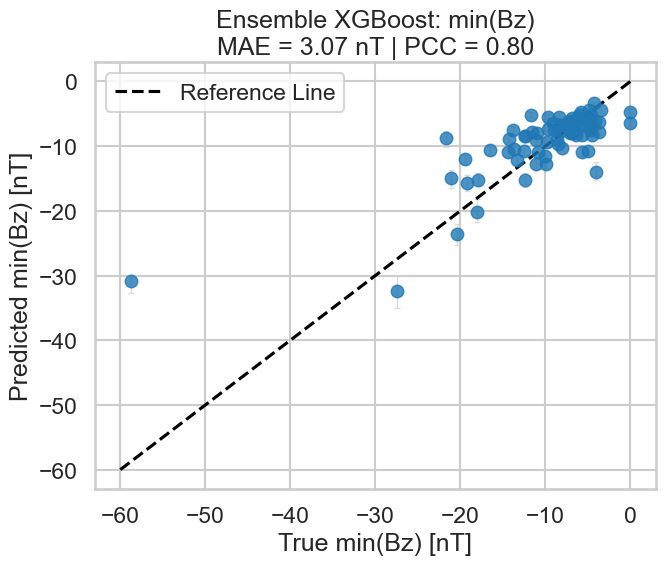

In [24]:
plt.figure(figsize=(7, 6))
plt.errorbar(
    y_test.ravel(), y_pred_mean,
    yerr=[y_pred_mean - y_pred_lower, y_pred_upper - y_pred_mean],
    fmt='o', ecolor='lightgray', elinewidth=1, capsize=2, alpha=0.8
)
plt.plot([-60, 0], [-60, 0], 'k--', label='Reference Line')
plt.xlabel('True min(Bz) [nT]')
plt.ylabel('Predicted min(Bz) [nT]')
plt.title(f'Ensemble XGBoost: min(Bz)\nMAE = {mae:.2f} nT | PCC = {pcc:.2f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## - Max(Btot)

## 2.2 Ensemble XGBoost for max(Bₜₒₜ) Prediction

In [25]:
# Replace Target with max(Btot)
train['Target'] = train['max(bt)']  # assuming column name is exactly this

# Bin target values into 5 quantiles for stratification
train['Target_bin'] = pd.qcut(train['Target'], q=5, labels=False)

# Stratified split
train_df, test_df = train_test_split(
    train,
    test_size=0.3,
    random_state=42,
    stratify=train['Target_bin']
)

# Drop bin column
train_df = train_df.drop(columns=['Target_bin'])
test_df = test_df.drop(columns=['Target_bin'])

# Select features (excluding 'Target')
use_features = [col for col in train_df.columns if col != 'Target']
X_train = train_df[use_features].to_numpy()
X_test  = test_df[use_features].to_numpy()
y_train = train_df['Target'].to_numpy().reshape(-1, 1)
y_test  = test_df['Target'].to_numpy().reshape(-1, 1)


# Standardization + reshape
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



In [26]:
import xgboost as xgb
import numpy as np

n_models = 20
seed_list = list(range(200, 200 + n_models))  # use different seed range for clarity

y_preds_bt = []

for seed in seed_list:
    model = xgb.XGBRegressor(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=seed,
        verbosity=0
    )
    
    model.fit(X_train_scaled, y_train.ravel())
    y_preds_bt.append(model.predict(X_test_scaled))


In [27]:
y_preds_bt_array = np.vstack(y_preds_bt).T  # shape: (n_samples, n_models)

y_pred_mean_bt  = np.mean(y_preds_bt_array, axis=1)
y_pred_lower_bt = np.percentile(y_preds_bt_array, 10, axis=1)
y_pred_upper_bt = np.percentile(y_preds_bt_array, 90, axis=1)


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

mae_bt = mean_absolute_error(y_test.ravel(), y_pred_mean_bt)
rmse_bt = np.sqrt(mean_squared_error(y_test.ravel(), y_pred_mean_bt))
pcc_bt = pearsonr(y_test.ravel(), y_pred_mean_bt)[0]
mae_baseline_bt = mean_absolute_error(y_test.ravel(), [np.mean(y_train)] * len(y_test))
ss_bt = 1 - (mae_bt / mae_baseline_bt)

print(f"Ensemble MAE (Btot)        = {mae_bt:.2f} nT")
print(f"Ensemble RMSE (Btot)       = {rmse_bt:.2f} nT")
print(f"Ensemble PCC (Btot)        = {pcc_bt:.2f}")
print(f"Ensemble SkillScore (Btot) = {ss_bt:.2f}")


Ensemble MAE (Btot)        = 0.78 nT
Ensemble RMSE (Btot)       = 3.34 nT
Ensemble PCC (Btot)        = 0.96
Ensemble SkillScore (Btot) = 0.88


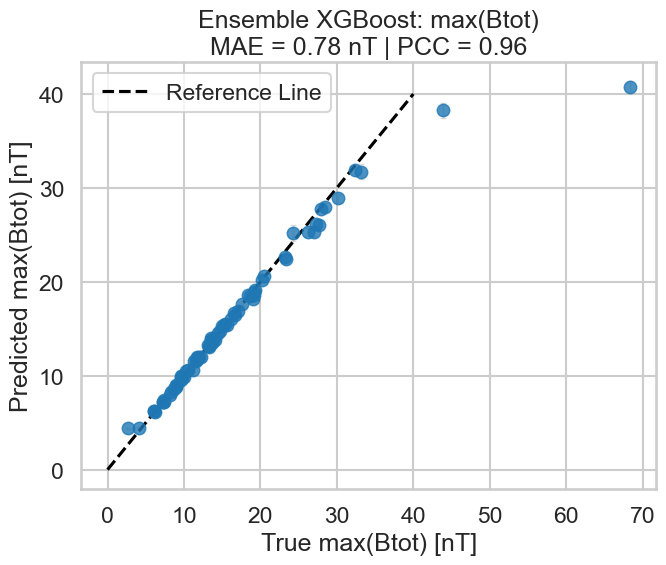

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.errorbar(
    y_test.ravel(), y_pred_mean_bt,
    yerr=[y_pred_mean_bt - y_pred_lower_bt, y_pred_upper_bt - y_pred_mean_bt],
    fmt='o', ecolor='lightgray', elinewidth=1, capsize=2, alpha=0.8
)
plt.plot([0, 40], [0, 40], 'k--', label='Reference Line')
plt.xlabel('True max(Btot) [nT]')
plt.ylabel('Predicted max(Btot) [nT]')
plt.title(f'Ensemble XGBoost: max(Btot)\nMAE = {mae_bt:.2f} nT | PCC = {pcc_bt:.2f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
